In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score

import mlflow
mlflow.set_tracking_uri('http://localhost:5000')
mlflow.set_experiment('finops-anomaly-detection')

from src.detection.threshold_detector import detect_with_forecast
from src.detection.isolation_forest import train_isolation_forest
from src.models.prophet_model import train_prophet

df = pd.read_csv('../data/raw/cloud_costs.csv', parse_dates=['date'])
services = ['EC2', 'S3', 'RDS', 'Lambda', 'CloudFront', 'EKS', 'Redshift']
print(f"Données chargées : {len(df)} lignes")

Données chargées : 7672 lignes


In [9]:
threshold_results = {}

for service in services:
    # Entraîner Prophet
    prophet_res = train_prophet(df, service)
    
    # Préparer les données réelles
    df_real = (df[df.service == service]
               .groupby('date')['cost_usd'].sum()
               .reset_index())
    
    # Préparer le forecast au bon format
    ts = (df[df.service == service]
          .groupby('date')['cost_usd'].sum()
          .reset_index()
          .rename(columns={'date':'ds','cost_usd':'y'}))
    
    future   = prophet_res['model'].make_future_dataframe(periods=0)
    forecast = prophet_res['model'].predict(future)
    forecast = forecast.rename(columns={'ds': 'date'})
    
    # Fusionner réel et forecast
    merged = df_real.merge(forecast[['date','yhat']], on='date')
    
    # Détecter les anomalies
    result = detect_with_forecast(merged, forecast)
    threshold_results[service] = result
    
    n = result['is_anomaly'].sum()
    print(f"{service} — {n} anomalies détectées")

22:39:32 - cmdstanpy - INFO - Chain [1] start processing
22:39:33 - cmdstanpy - INFO - Chain [1] done processing


EC2 — PROPHET MAPE: 8.6%, RMSE: 57$
EC2 — 5 anomalies détectées


22:39:33 - cmdstanpy - INFO - Chain [1] start processing
22:39:33 - cmdstanpy - INFO - Chain [1] done processing


S3 — PROPHET MAPE: 8.7%, RMSE: 22$
S3 — 4 anomalies détectées


22:39:34 - cmdstanpy - INFO - Chain [1] start processing
22:39:34 - cmdstanpy - INFO - Chain [1] done processing


...

CloudFront — PROPHET MAPE: 8.0%, RMSE: 16$
CloudFront — 3 anomalies détectées


22:39:36 - cmdstanpy - INFO - Chain [1] start processing
22:39:36 - cmdstanpy - INFO - Chain [1] done processing


EKS — PROPHET MAPE: 8.4%, RMSE: 89$
EKS — 4 anomalies détectées


22:39:37 - cmdstanpy - INFO - Chain [1] start processing
22:39:37 - cmdstanpy - INFO - Chain [1] done processing


Redshift — PROPHET MAPE: 7.9%, RMSE: 55$
Redshift — 3 anomalies détectées


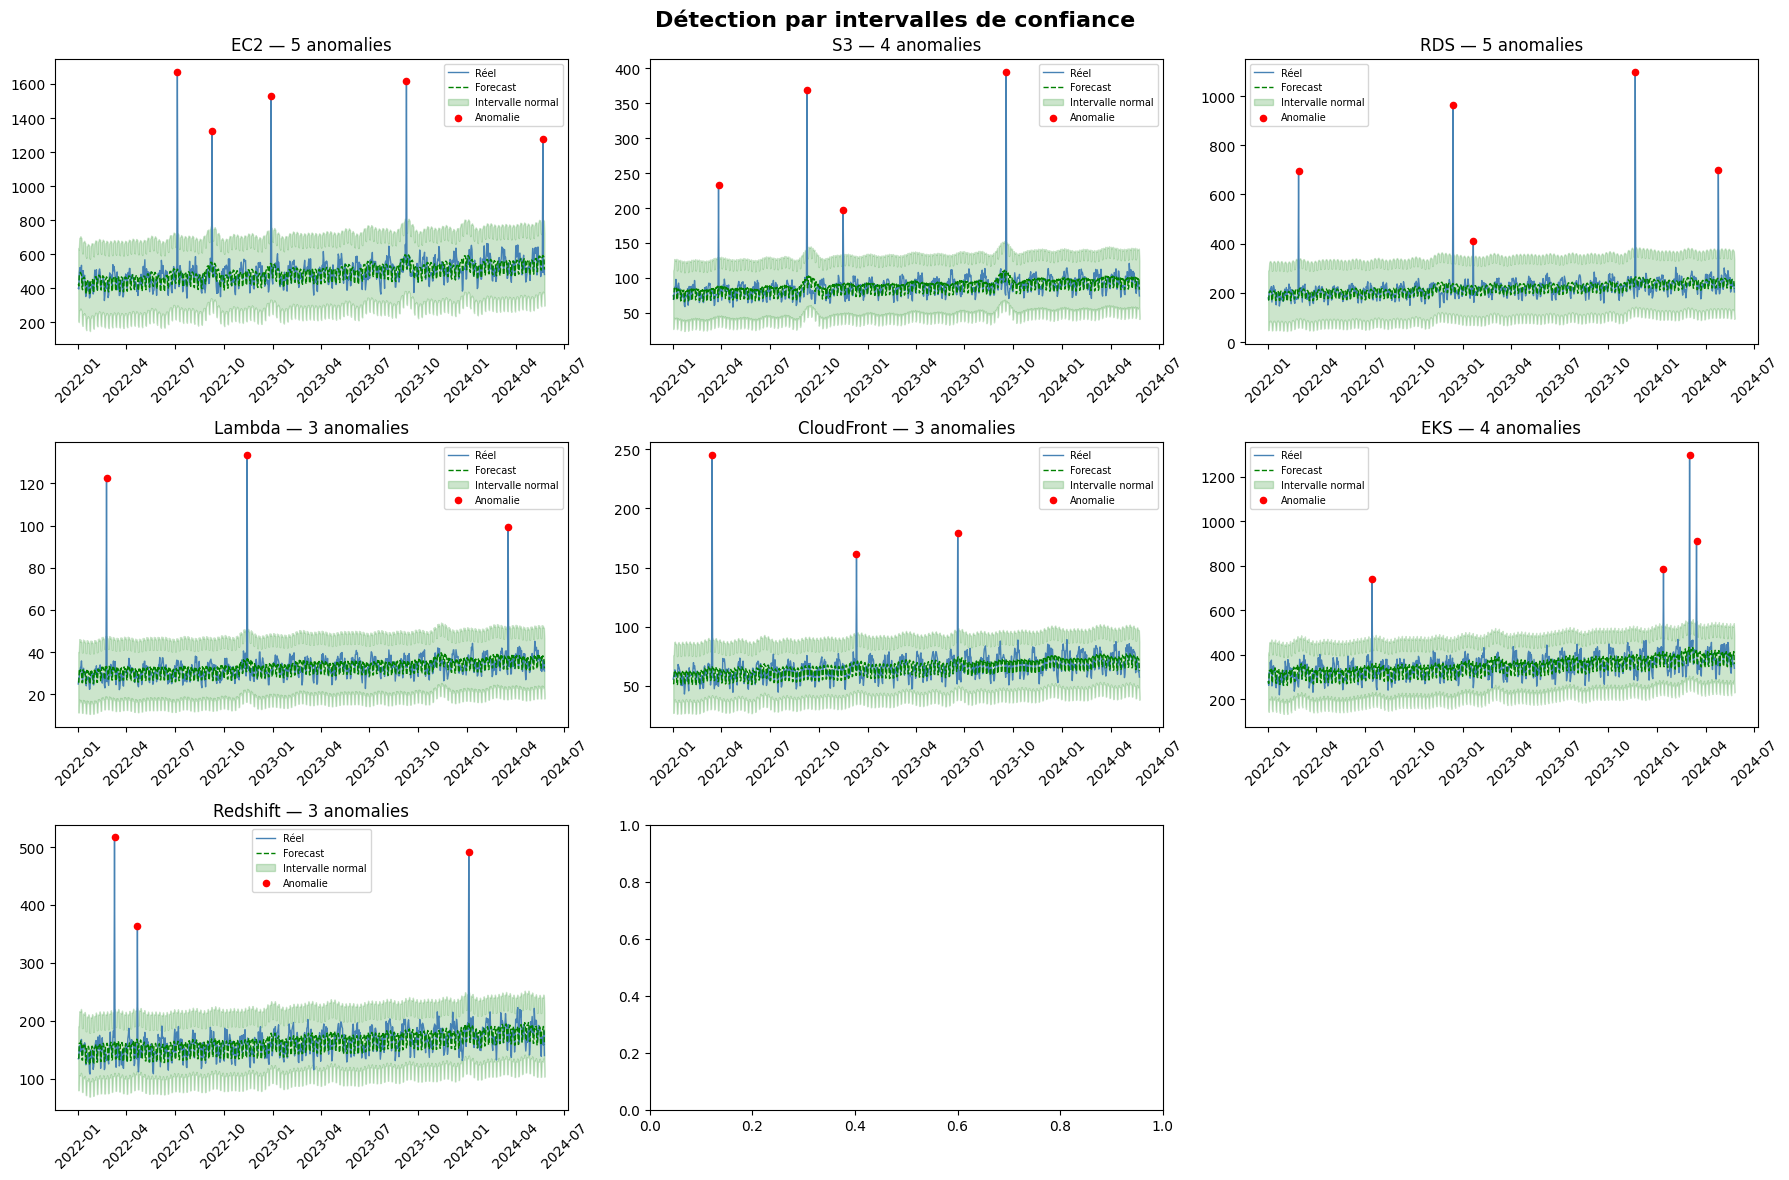

Graphique sauvegardé !


In [10]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, service in enumerate(services):
    ax    = axes[i]
    res   = threshold_results[service]
    
    # Coût réel
    ax.plot(res['date'], res['cost_usd'],
            label='Réel', color='steelblue', linewidth=1)
    
    # Prévision
    ax.plot(res['date'], res['forecast'],
            label='Forecast', color='green', linestyle='--', linewidth=1)
    
    # Bandes de confiance
    ax.fill_between(res['date'], res['lower_bound'], res['upper_bound'],
                    alpha=0.2, color='green', label='Intervalle normal')
    
    # Points anomalies en rouge
    anomalies = res[res['is_anomaly']]
    ax.scatter(anomalies['date'], anomalies['cost_usd'],
               color='red', zorder=5, label='Anomalie', s=20)
    
    ax.set_title(f"{service} — {res['is_anomaly'].sum()} anomalies")
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
plt.suptitle('Détection par intervalles de confiance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/outputs/anomalies_threshold.png', dpi=150)
plt.show()
print("Graphique sauvegardé !")

In [11]:
clf, scaler, pivot = train_isolation_forest(df)

n_anomalies = (pivot['if_label'] == -1).sum()
print(f"Isolation Forest — {n_anomalies} jours anormaux détectés sur {len(pivot)} jours")
print(f"Soit {n_anomalies/len(pivot)*100:.1f}% des jours")

Isolation Forest détecte 55 anomalies sur 1096 jours (5.0%)
Isolation Forest — 55 jours anormaux détectés sur 1096 jours
Soit 5.0% des jours


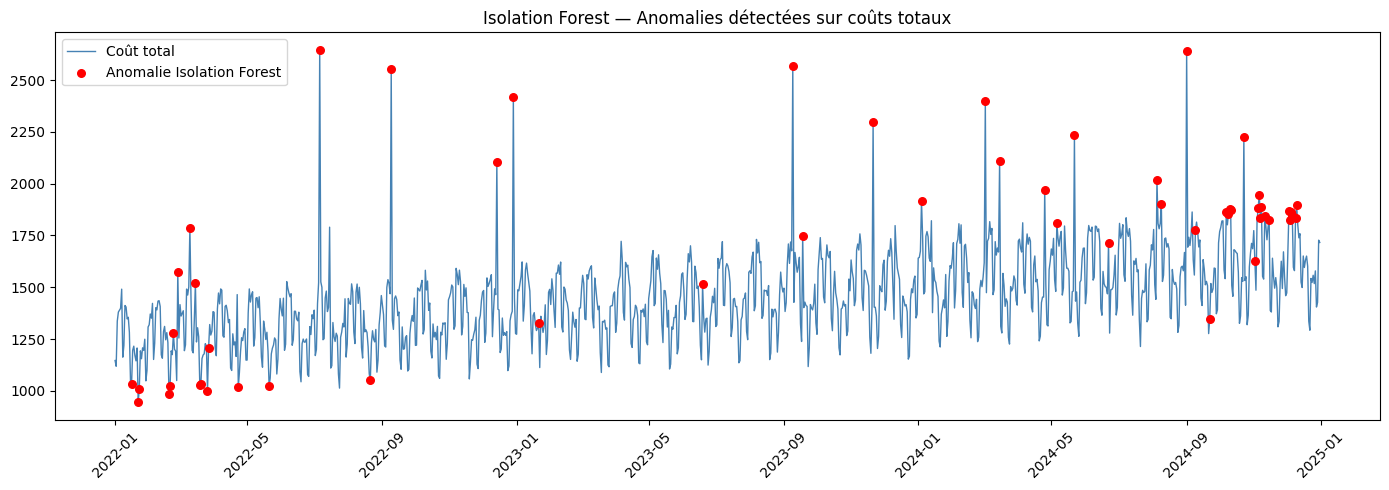

In [12]:
plt.figure(figsize=(14, 5))

# Coût total par jour
daily_total = df.groupby('date')['cost_usd'].sum()
plt.plot(daily_total.index, daily_total.values,
         color='steelblue', linewidth=1, label='Coût total')

# Jours anomalies en rouge
anomaly_dates = pivot[pivot['if_label'] == -1].index
anomaly_costs = daily_total[daily_total.index.isin(anomaly_dates)]
plt.scatter(anomaly_costs.index, anomaly_costs.values,
            color='red', zorder=5, s=30, label='Anomalie Isolation Forest')

plt.title('Isolation Forest — Anomalies détectées sur coûts totaux')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../notebooks/outputs/anomalies_isolation_forest.png', dpi=150)
plt.show()